In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv")

In [22]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,0,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,0,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,1,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,0,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,0,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910


In [5]:
df.shape

(4455, 14)

In [7]:
df.dtypes

status       object
seniority     int64
home         object
time          int64
age           int64
marital      object
records      object
job          object
expenses      int64
income        int64
assets        int64
debt          int64
amount        int64
price         int64
dtype: object

In [3]:
#Format column names
df.columns = df.columns.str.lower()

Note that all the features are presented as numerical variables, but some of them are actually categorical variables. Let's modify them. We do so by performing mappings, which requires us to first define dictionaries for the rules we will use to assign categorical features to these variables.

In [4]:
status_values = {
  1: "ok",
  2: "default",
  0: "unknown"
}
df.status = df.status.map(status_values)
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}
df.home = df.home.map(home_values)
 
marital_values = {
    1: 'single', 
    2: 'married', 
    3: 'widow', 
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}
df.marital = df.marital.map(marital_values)
 
records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}
df.records = df.records.map(records_values)
 
job_values = {
    1: 'fixed', 
    2: 'partime', 
    3: 'freelance', 
    4: 'others',
    0: 'unk'
}
df.job = df.job.map(job_values)

Once encoded, we can take a closer look at the statistics. To do so, these is the describe() function (unfortunately, it didn't work as int he tutorial, possible version deprecation).

In [12]:
for var in df.columns:
  print(f"{var}: {df[var].max()}")

status: unknown
seniority: 48
home: unk
time: 72
age: 68
marital: widow
records: yes
job: unk
expenses: 180
income: 99999999
assets: 99999999
debt: 99999999
amount: 5000
price: 11140


We can note that the variables income, assets, and debt have extremely large values, which can be considered as outliers. We replace them with NaN. Then, we replece these values by the average of the remaining points.

In [5]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)
    df[c] = df[c].fillna(df[c].mean())

In [30]:
df.status.value_counts()

status
ok         3200
default    1254
unknown       1
Name: count, dtype: int64

Since our target variable is "status", and the only values we are interested in for this are "ok" and "default", we can safely remove from the data frame the rows with "unknown" value in this feature. In addition, we have to convert the target variable into 0's ans 1's.

In [6]:
df = df[df.status != "unknown"].reset_index(drop=True)

st_to_int = {"ok": 0, "default": 1}
df.status = df.status.map(st_to_int)

In [7]:
# Dataset splitting
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

y_train = df_train.status
y_val = df_val.status
y_test = df_test.status

# Now we can use DictVectorizer to convert the list of dictionaries into a feature matrix
dv = DictVectorizer(sparse=False)

train_dict = df_train.drop(['status'], axis=1).to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.drop(['status'], axis=1).to_dict(orient='records')
X_val = dv.transform(val_dict)

Now, we train a decision tree.

In [8]:
for n in [3,5,None,1]:

  clf = DecisionTreeClassifier(max_depth=n)
  clf.fit(X_train, y_train)

  y_pred = clf.predict_proba(X_val)[:,1]
  print(f"max depth: {n}\nValidations score: {roc_auc_score(y_val, y_pred)}")

  y_pred = clf.predict_proba(X_train)[:,1]
  print("Training score: ", roc_auc_score(y_train, y_pred))

max depth: 3
Validations score: 0.7376244217868301
Training score:  0.7727018900343643
max depth: 5
Validations score: 0.7646551306580127
Training score:  0.8404047659286802


max depth: None
Validations score: 0.6661984451817589
Training score:  1.0
max depth: 1
Validations score: 0.6058644740984719
Training score:  0.6282660131823559


In [67]:
print(export_text(clf))

|--- feature_25 <= 0.50
|   |--- class: 1
|--- feature_25 >  0.50
|   |--- class: 0



Let's go on with this parameter tuning.

In [9]:
scores = []
for n in range(11):
  for m in range(11):
    nn = int(2**n)
    mm = int(2**m)
    clf = DecisionTreeClassifier(max_depth=nn, min_samples_leaf=mm)
    clf.fit(X_train, y_train)

    y_pred = clf.predict_proba(X_val)[:,1]
    scores.append([nn, mm, roc_auc_score(y_val, y_pred)])

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

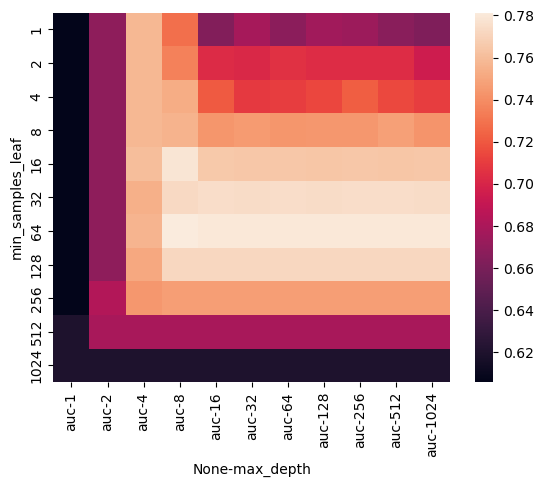

In [19]:
df_scores = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc'])
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
df_scores_pivot.round(3)

sns.heatmap(df_scores_pivot, annot=False, fmt=".3f")

In [33]:
np.unravel_index(np.argmax(df_scores_pivot.values[1:,1:]), df_scores_pivot.values[1:,1:].shape)

(np.int64(5), np.int64(2))

In [35]:
df_scores_pivot.values[6,3]

np.float64(0.7813597394105252)

In [38]:
clf = DecisionTreeClassifier(max_depth=8, min_samples_leaf=64)
clf.fit(X_train, y_train)

y_pred = clf.predict_proba(X_val)[:,1]
print("AUC:", roc_auc_score(y_val, y_pred))

AUC: 0.7813597394105252
